# Название проекта и описание задачи

 # Прогноз отмены бронирования

- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.

## Цель проекта — разработать модель машинного, которая прогнозирует вероятность отмены бронирования.

Модель должна:
- минимизировать финансовые потери от отмен;
- повысить загрузку отелей;
- позволить принимать решения о повторном бронировании.
## Данные

1. hotel_bookings — содержит информацию о бронированиях:
   - даты бронирования
   - характеристики клиента
   - параметры проживания
   - факт отмены

2. hotel_reviews — содержит информацию об отзывах:
   - текст отзыва
   - оценка
   - дата отзыва

## Перевод бизнес-задачи на язык машинного обучения

- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.

## Задача бинарной классификации:

- 1 — бронирование будет отменено
- 0 — бронирование состоится

Основные шаги:
- подготовка данных
- обучение моделей (CatBoost, RandomForest и др.)
- оптимизация по метрике IR
- подбор оптимального порога классификации
- оценка модели

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
!pip install optuna catboost xgboost scikit-learn seaborn --quiet


import pandas as pd

from catboost import Pool, CatBoostClassifier
from xgboost import XGBClassifier
import numpy as np
from xgboost import XGBClassifier
from sqlalchemy import create_engine
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.calibration import CalibratedClassifierCV
import psycopg2
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from catboost import CatBoostClassifier
!pip freeze

/Users/aleksandrstepanov/yandex/project4/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


alembic==1.18.4
anyio==4.13.0
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.14.3
bleach==6.3.0
catboost==1.2.10
certifi==2026.2.25
cffi==2.0.0
charset-normalizer==3.4.7
colorlog==6.10.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.62.1
fqdn==1.5.1
graphviz==0.21
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.11
ipykernel==7.2.0
ipython==9.12.0
ipython_pygments_lexers==1.1.1
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.14.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter-events==0.12.0
jupyter-lsp==2.3.1
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.6
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
kiwisolver==1.5.0
lark==1.3.1
Mako==1.3.11
Mar

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

In [2]:
engine = create_engine(
    ''
)

query_bookings = "SELECT * FROM hotel_bookings"
query_reviews = "SELECT * FROM hotel_reviews"

bookings = pd.read_sql_query(query_bookings, engine)
reviews = pd.read_sql_query(query_reviews, engine)

In [3]:
reviews.head()


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


**hotel_bookings** — содержит информацию о бронированиях:
- идентификатор бронирования (booking_id)
- дата бронирования (booking_date)
- канал продаж (sales_channel)
- параметры гостей (adult_count, child_count)
- история клиента (returning_customer, previous_cancellations, previous_no_shows)
- параметры проживания (weekday_nights, weekend_nights, meal_plan, room_type)
- стоимость бронирования (booking_value)
- статус бронирования (booking_status)

**hotel_reviews** — содержит информацию об отзывах:
- идентификатор клиента (customer_id)
- идентификатор бронирования (booking_id)
- дата отзыва (review_date)
- оценка проживания (stay_rating)
- текст отзыва (review_text)

## Вывод
Таблицы содержат числовые, категориальные признаки, текстовые данные


### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [4]:
bookings.info()
reviews.info()


<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

In [5]:
bookings = bookings[bookings['adult_count'] > 0]

bookings = bookings[bookings['booking_value'] > 0]

bookings['meal_plan'] = bookings['meal_plan'].replace(r'^\s*$', 'Unknown', regex=True)

bookings = bookings.drop_duplicates()

bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

Аномальные значения adult_count (>10):
adult_count
100    848
200    830
300    376
Name: count, dtype: int64

Уникальные значения meal_plan:
<StringArray>
['тип_питания_2', 'тип_питания_1', 'не выбран', 'не выбрант', 'тип_питания_3']
Length: 5, dtype: str

Распределение meal_plan:
meal_plan
тип_питания_1    22665
не выбран         3703
тип_питания_2     2712
не выбрант         419
тип_питания_3        5
Name: count, dtype: int64

Пустые значения в meal_plan: 0


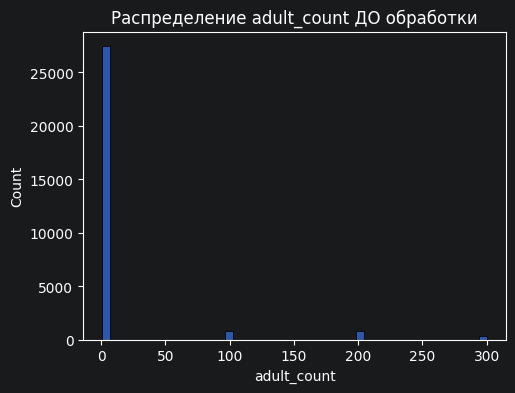

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(bookings['adult_count'], bins=50)
plt.title('Распределение adult_count ДО обработки')

print("Аномальные значения adult_count (>10):")
print(bookings[bookings['adult_count'] > 10]['adult_count'].value_counts())

print("\nУникальные значения meal_plan:")
print(bookings['meal_plan'].unique())
print("\nРаспределение meal_plan:")
print(bookings['meal_plan'].value_counts(dropna=False))

print(f"\nПустые значения в meal_plan: {(bookings['meal_plan'].str.strip() == '').sum()}")

bookings.loc[bookings['adult_count'] > 10, 'adult_count'] = bookings.loc[bookings['adult_count'] > 10, 'adult_count'] // 10
bookings['meal_plan'] = bookings['meal_plan'].str.strip()
bookings['meal_plan'] = bookings['meal_plan'].replace('', 'Unknown')

In [7]:
bookings.loc[bookings['adult_count'] > 10, 'adult_count'] = bookings.loc[bookings['adult_count'] > 10, 'adult_count'] // 100

bookings['meal_plan'] = bookings['meal_plan'].str.strip()
bookings['meal_plan'] = bookings['meal_plan'].replace('не выбрант', 'не выбран')

print("После обработки:")
print(bookings['adult_count'][bookings['adult_count'] > 10].value_counts())
print(bookings['meal_plan'].value_counts())

После обработки:
Series([], Name: count, dtype: int64)
meal_plan
тип_питания_1    22665
не выбран         4122
тип_питания_2     2712
тип_питания_3        5
Name: count, dtype: int64


In [8]:
print("После обработки adult_count:")
print(bookings['adult_count'].value_counts().sort_index())
print(f"\nМаксимальное количество взрослых: {bookings['adult_count'].max()}")

print("Аномальные значения adult_count (>10) после обработки:")
anomalies = bookings[bookings['adult_count'] > 10]['adult_count'].value_counts()
if len(anomalies) > 0:
    print(anomalies)
else:
    print("Аномалий не осталось")

После обработки adult_count:
adult_count
0      1206
1     11008
2     10835
3      5607
10      848
Name: count, dtype: int64

Максимальное количество взрослых: 10
Аномальные значения adult_count (>10) после обработки:
Аномалий не осталось


In [9]:
bookings.adult_count.unique()

array([ 0,  3,  2,  1, 10])

In [10]:
print(bookings.isna().sum())
print(reviews.isna().sum())
print(bookings.duplicated().sum())
print(reviews.duplicated().sum())

booking_id                   0
booking_date                 0
sales_channel                0
adult_count                  0
child_count                  0
returning_customer           0
previous_cancellations       0
previous_no_shows            0
booking_status               0
booking_value                0
days_until_checkin           0
weekday_nights               0
weekend_nights               0
meal_plan                    0
parking_included             0
room_type                    0
customer_special_requests    0
dtype: int64
customer_id    0
booking_id     0
review_date    0
stay_rating    0
review_text    0
dtype: int64
0
0


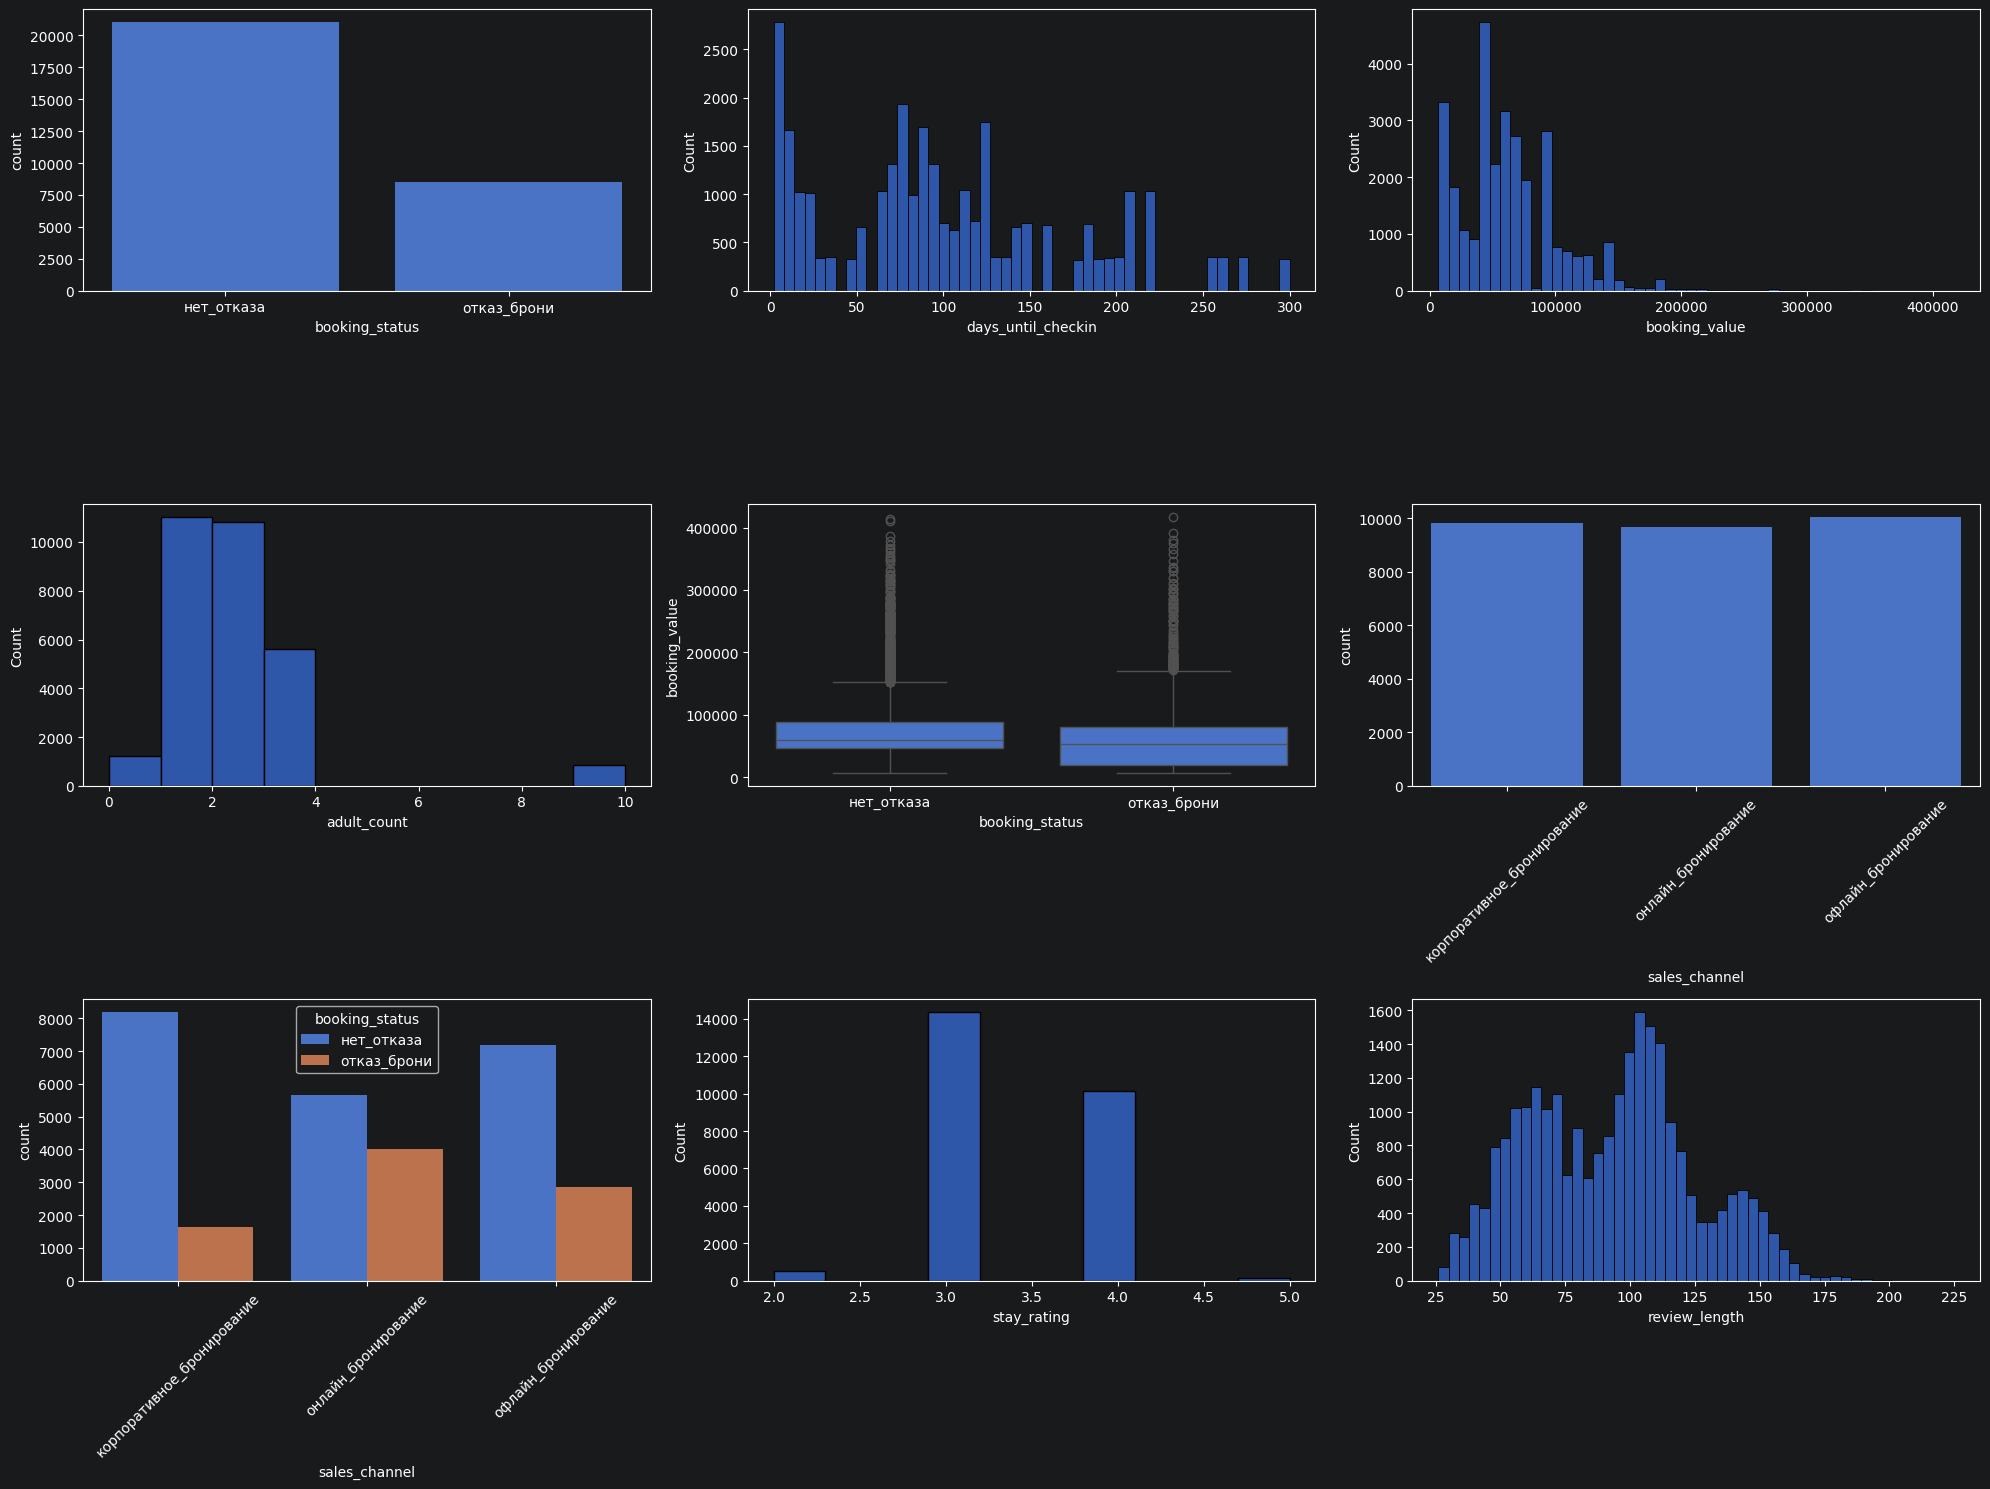

In [11]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
sns.countplot(x='booking_status', data=bookings)

plt.subplot(3, 3, 2)
sns.histplot(bookings['days_until_checkin'], bins=50)

plt.subplot(3, 3, 3)
sns.histplot(bookings['booking_value'], bins=50)

plt.subplot(3, 3, 4)
sns.histplot(bookings['adult_count'], bins=10)

plt.subplot(3, 3, 5)
sns.boxplot(x='booking_status', y='booking_value', data=bookings)

plt.subplot(3, 3, 6)
sns.countplot(x='sales_channel', data=bookings)
plt.xticks(rotation=45)

plt.subplot(3, 3, 7)
sns.countplot(x='sales_channel', hue='booking_status', data=bookings)
plt.xticks(rotation=45)

plt.subplot(3, 3, 8)
sns.histplot(reviews['stay_rating'], bins=10)

reviews['review_length'] = reviews['review_text'].str.len()

plt.subplot(3, 3, 9)
sns.histplot(reviews['review_length'], bins=50)

plt.tight_layout()
plt.show()

# Пропуски

В обеих таблицах пропуски отсутствуют

# Дубликаты

- В таблице hotel_bookings обнаружено 4608 дубликатов
- В таблице hotel_reviews дубликаты отсутствуют

# Типы данных

Обнаружены следующие особенности:
- признаки booking_date и review_date имеют тип object и требуют преобразования в datetime
- категориальные признаки (sales_channel, meal_plan, room_type)
- булевы признаки уже имеют корректный тип (returning_customer, parking_included)

# Вывод
требуется:
- удалить дубликаты
- преобразовать даты в формат datetime

In [12]:
bookings = bookings.drop_duplicates()

bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [13]:
df = bookings.merge(
    reviews[['customer_id', 'booking_id']],
    on='booking_id',
    how='left'
)

reviews_sorted = reviews.sort_values('review_date')
bookings_sorted = df.sort_values('booking_date')

df = pd.merge_asof(
    bookings_sorted,
    reviews_sorted,
    by='customer_id',
    left_on='booking_date',
    right_on='review_date',
    direction='backward',
    allow_exact_matches=False
)
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 32659 entries, 0 to 32658
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id_x               32659 non-null  str          
 1   booking_date               32659 non-null  datetime64[s]
 2   sales_channel              32659 non-null  str          
 3   adult_count                32659 non-null  int64        
 4   child_count                32659 non-null  int64        
 5   returning_customer         32659 non-null  bool         
 6   previous_cancellations     32659 non-null  int64        
 7   previous_no_shows          32659 non-null  int64        
 8   booking_status             32659 non-null  str          
 9   booking_value              32659 non-null  float64      
 10  days_until_checkin         32659 non-null  int64        
 11  weekday_nights             32659 non-null  int64        
 12  weekend_nights             32

(32659, 23)

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

In [14]:
df['total_nights'] = df['weekday_nights'] + df['weekend_nights']
df['total_guests'] = df['adult_count'] + df['child_count']
df['is_weekend_stay'] = (df['weekend_nights'] > 0).astype(int)

df['booking_month'] = df['booking_date'].dt.month
df['season'] = df['booking_month'] % 12 // 3 + 1
df['is_high_season'] = df['season'].isin([2, 3]).astype(int)

df['loyalty'] = df['previous_cancellations'] + df['previous_no_shows']

In [15]:
df['review_length'] = df['review_text'].fillna('').apply(len)
df['review_positive'] = (df['stay_rating'] >= 4).astype(int)
df['review_text'] = df['review_text'].fillna('')

In [16]:
print(df['booking_status'].unique())
df['target'] = (df['booking_status'] == 'отказ_брони').astype(int)
print(df['target'].value_counts())

df = df.reset_index(drop=True)

<StringArray>
['нет_отказа', 'отказ_брони']
Length: 2, dtype: str
target
0    24167
1     8492
Name: count, dtype: int64


### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

In [17]:
print(df.head())
print(df.info())
print(df.isna().sum().sort_values(ascending=False))
print(df.duplicated().sum())

  booking_id_x booking_date        sales_channel  adult_count  child_count  \
0     INN21754   2017-01-01  онлайн_бронирование            3            2   
1     INN21754   2017-01-01  онлайн_бронирование            3            2   
2     INN00177   2017-01-01  онлайн_бронирование            2            0   
3     INN20018   2017-01-01  онлайн_бронирование            3            0   
4     INN21754   2017-01-01  онлайн_бронирование            3            2   

   returning_customer  previous_cancellations  previous_no_shows  \
0               False                       0                  0   
1               False                       0                  0   
2               False                       0                  0   
3                True                       1                  1   
4               False                       0                  0   

  booking_status  booking_value  ...  review_length  total_nights  \
0     нет_отказа        67000.0  ...              0  

# Анализ итоговой таблицы

После объединения данных и создания новых признаков была получена итоговая таблица, содержащая 34 027 записей и 31 признак.

# Общая структура данных

В таблице представлены различные типы признаков:

- числовые: booking_value, days_until_checkin, total_nights, total_guests
- категориальные: sales_channel, meal_plan, room_type
- булевы: returning_customer, parking_included, review_positive
- временные: booking_date, review_date
- поведенческие: previous_cancellations, previous_no_shows, loyalty
- производные: сезонность, длительность проживания, количество гостей

Сформирована целевая переменная target, отражающая факт отмены бронирования.

# Пропуски

В данных присутствуют пропуски, связанные с отзывами:

- stay_rating — 24 437 пропусков
- review_date — 24 437 пропусков
- booking_id_y — 24 437 пропусков
- customer_id — 8 850 пропусков

Пропуски объясняются отсутствием отзывов у части клиентов

# Особенности данных

- Признак review_length равен 0 для большинства записей, что подтверждает отсутствие отзывов
- Поведенческие признаки (loyalty, previous_cancellations) могут быть важными предикторами отмен
- Сезонные признаки позволяют учитывать влияние времени года на поведение клиентов

# Вывод

Перед обучением модели необходимо:
- обработать пропуски (при необходимости)
- закодировать категориальные признаки

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

In [18]:
"""cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'target' in cat_cols:
    cat_cols.remove('target')

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df[cat_cols])
encoded_columns = encoder.get_feature_names_out(cat_cols)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_columns, index=df.index)

num_cols = df.select_dtypes(exclude=['object', 'string']).columns.tolist()
df_final = pd.concat([df[num_cols], df_encoded], axis=1)
df_final['target'] = df['target']
df = df_final"""


review_texts = df['review_text'].fillna('')

AVG_REV = 64500
COST_FP = 7000
PER_REBOOKING = 45000
LOST_REV = 64500

df = df.sort_values('booking_date').reset_index(drop=True)
target = df['target']
drop_cols = ['target', 'booking_id', 'booking_id_x', 'booking_id_y', 'customer_id', 'booking_date', 'review_date', 'booking_status', 'review_text']
features_df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

cat_features = features_df.select_dtypes(include=['object', 'string']).columns.tolist()
features_df[cat_features] = features_df[cat_features].astype('category')

n = len(features_df)
train_end = int(n * 0.6)
calib_end = int(n * 0.8)

X_train = features_df.iloc[:train_end]
y_train = target.iloc[:train_end]
X_calib = features_df.iloc[train_end:calib_end]
y_calib = target.iloc[train_end:calib_end]
X_test = features_df.iloc[calib_end:]
y_test = target.iloc[calib_end:]

"""vectorizer = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))
tfidf_train = vectorizer.fit_transform(review_texts.iloc[:train_end])
tfidf_calib = vectorizer.transform(review_texts.iloc[train_end:calib_end])
tfidf_test = vectorizer.transform(review_texts.iloc[calib_end:])

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_train.shape[1])]

X_train_tfidf = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_cols, index=X_train.index)
X_calib_tfidf = pd.DataFrame(tfidf_calib.toarray(), columns=tfidf_cols, index=X_calib.index)
X_test_tfidf = pd.DataFrame(tfidf_test.toarray(), columns=tfidf_cols, index=X_test.index)

X_train = pd.concat([X_train, X_train_tfidf], axis=1)
X_calib = pd.concat([X_calib, X_calib_tfidf], axis=1)
X_test = pd.concat([X_test, X_test_tfidf], axis=1)"""

"vectorizer = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))\ntfidf_train = vectorizer.fit_transform(review_texts.iloc[:train_end])\ntfidf_calib = vectorizer.transform(review_texts.iloc[train_end:calib_end])\ntfidf_test = vectorizer.transform(review_texts.iloc[calib_end:])\n\ntfidf_cols = [f'tfidf_{i}' for i in range(tfidf_train.shape[1])]\n\nX_train_tfidf = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_cols, index=X_train.index)\nX_calib_tfidf = pd.DataFrame(tfidf_calib.toarray(), columns=tfidf_cols, index=X_calib.index)\nX_test_tfidf = pd.DataFrame(tfidf_test.toarray(), columns=tfidf_cols, index=X_test.index)\n\nX_train = pd.concat([X_train, X_train_tfidf], axis=1)\nX_calib = pd.concat([X_calib, X_calib_tfidf], axis=1)\nX_test = pd.concat([X_test, X_test_tfidf], axis=1)"

In [19]:

def calculate_ir(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    ir_before = ((y_true == 0).sum() * AVG_REV) - ((y_true == 1).sum() * LOST_REV)
    ir_after = (tn * AVG_REV) + (tp * PER_REBOOKING) - (fp * COST_FP) - (fn * LOST_REV)
    return ir_after, ir_before, tp, tn, fp, fn

In [20]:
"""tscv = TimeSeriesSplit(n_splits=3)

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 200),
        'depth': trial.suggest_int('depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 15),
        'logging_level': 'Silent',
        'random_state': 42
    }
    ir_list = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features)
        probs = model.predict_proba(X_val)[:, 1]
        best_ir = -np.inf
        for t in np.linspace(0.1, 0.9, 20):
            preds = (probs > t).astype(int)
            ir, _, _, _, _, _ = calculate_ir(y_val, preds)
            if ir > best_ir: best_ir = ir
        ir_list.append(best_ir)
    return np.mean(ir_list)

def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'verbosity': 0,
        'random_state': 42,
        'enable_categorical': True,
        'eval_metric': 'logloss'
    }
    ir_list = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_val)[:, 1]
        best_ir = -np.inf
        for t in np.linspace(0.1, 0.9, 20):
            preds = (probs > t).astype(int)
            ir, _, _, _, _, _ = calculate_ir(y_val, preds)
            if ir > best_ir: best_ir = ir
        ir_list.append(best_ir)
    return np.mean(ir_list)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_catboost, n_trials=10, show_progress_bar=False)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=10, show_progress_bar=False)"""

X_train_base = features_df.iloc[:train_end].copy()
y_train_full = target.iloc[:train_end].copy()
review_texts_train = df['review_text'].fillna('').iloc[:train_end].copy()

cat_features_list = [col for col in cat_features if col in X_train_base.columns]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if cat_features_list:
    encoder.fit(X_train_base[cat_features_list].astype(str))

tscv = TimeSeriesSplit(n_splits=3)

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 200),
        'depth': trial.suggest_int('depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 15),
        'logging_level': 'Silent',
        'random_state': 42
    }
    ir_list = []

    for train_idx, val_idx in tscv.split(X_train_base):
        X_tr = X_train_base.iloc[train_idx].copy()
        X_val = X_train_base.iloc[val_idx].copy()
        y_tr = y_train_full.iloc[train_idx]
        y_val = y_train_full.iloc[val_idx]
        txt_tr = review_texts_train.iloc[train_idx]
        txt_val = review_texts_train.iloc[val_idx]

        vec = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))
        tfidf_tr = vec.fit_transform(txt_tr)
        tfidf_val = vec.transform(txt_val)
        tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_tr.shape[1])]

        X_tr = pd.concat([X_tr, pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=X_tr.index)], axis=1)
        X_val = pd.concat([X_val, pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=X_val.index)], axis=1)

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features)

        probs = model.predict_proba(X_val)[:, 1]
        best_ir = -np.inf
        for t in np.linspace(0.1, 0.9, 20):
            preds = (probs > t).astype(int)
            ir, _, _, _, _, _ = calculate_ir(y_val, preds)
            if ir > best_ir:
                best_ir = ir
        ir_list.append(best_ir)

    return np.mean(ir_list)


def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'verbosity': 0,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    ir_list = []

    for train_idx, val_idx in tscv.split(X_train_base):
        X_tr = X_train_base.iloc[train_idx].copy()
        X_val = X_train_base.iloc[val_idx].copy()
        y_tr = y_train_full.iloc[train_idx]
        y_val = y_train_full.iloc[val_idx]
        txt_tr = review_texts_train.iloc[train_idx]
        txt_val = review_texts_train.iloc[val_idx]

        vec = TfidfVectorizer(max_features=50, min_df=5, max_df=0.8, ngram_range=(1, 2))
        tfidf_tr = vec.fit_transform(txt_tr)
        tfidf_val = vec.transform(txt_val)
        tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_tr.shape[1])]

        X_tr = pd.concat([X_tr, pd.DataFrame(tfidf_tr.toarray(), columns=tfidf_cols, index=X_tr.index)], axis=1)
        X_val = pd.concat([X_val, pd.DataFrame(tfidf_val.toarray(), columns=tfidf_cols, index=X_val.index)], axis=1)

        if cat_features_list:
            X_tr[cat_features_list] = encoder.transform(X_tr[cat_features_list].astype(str))
            X_val[cat_features_list] = encoder.transform(X_val[cat_features_list].astype(str))

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        probs = model.predict_proba(X_val)[:, 1]
        best_ir = -np.inf
        for t in np.linspace(0.1, 0.9, 20):
            preds = (probs > t).astype(int)
            ir, _, _, _, _, _ = calculate_ir(y_val, preds)
            if ir > best_ir:
                best_ir = ir
        ir_list.append(best_ir)

    return np.mean(ir_list)

print("Оптимизация CatBoost...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_catboost, n_trials=10, show_progress_bar=True)
print(f"Лучший IR CatBoost: {study_cat.best_value:.0f}")
print(f"Лучшие параметры: {study_cat.best_params}")

print("\nОптимизация XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=10, show_progress_bar=True)
print(f"Лучший IR XGBoost: {study_xgb.best_value:.0f}")
print(f"Лучшие параметры: {study_xgb.best_params}")

[I 2026-04-24 19:49:25,662] A new study created in memory with name: no-name-db9f4bf7-848b-4444-8e6b-78bdb8c8a78e


Оптимизация CatBoost...


Best trial: 0. Best value: 2.0971e+08:  10%|█         | 1/10 [00:01<00:09,  1.10s/it]

[I 2026-04-24 19:49:26,771] Trial 0 finished with value: 209710333.33333334 and parameters: {'iterations': 139, 'depth': 4, 'learning_rate': 0.05254292005061082, 'l2_leaf_reg': 12.493776882064534}. Best is trial 0 with value: 209710333.33333334.


Best trial: 0. Best value: 2.0971e+08:  20%|██        | 2/10 [00:02<00:08,  1.04s/it]

...

[I 2026-04-24 19:49:46,475] Trial 7 finished with value: 208109833.33333334 and parameters: {'n_estimators': 175, 'max_depth': 5, 'learning_rate': 0.026008158314883453, 'reg_lambda': 4.95279412651559, 'subsample': 0.8665870702143185}. Best is trial 7 with value: 208109833.33333334.


Best trial: 7. Best value: 2.0811e+08:  90%|█████████ | 9/10 [00:09<00:00,  1.04it/s]

[I 2026-04-24 19:49:47,345] Trial 8 finished with value: 207651833.33333334 and parameters: {'n_estimators': 144, 'max_depth': 5, 'learning_rate': 0.13132488089161845, 'reg_lambda': 11.274469682053821, 'subsample': 0.8239442553505769}. Best is trial 7 with value: 208109833.33333334.


Best trial: 9. Best value: 2.08644e+08: 100%|██████████| 10/10 [00:09<00:00,  1.03it/s]

[I 2026-04-24 19:49:48,054] Trial 9 finished with value: 208643500.0 and parameters: {'n_estimators': 136, 'max_depth': 4, 'learning_rate': 0.11524626576907719, 'reg_lambda': 12.311807741497168, 'subsample': 0.8266050463800493}. Best is trial 9 with value: 208643500.0.
Лучший IR XGBoost: 208643500
Лучшие параметры: {'n_estimators': 136, 'max_depth': 4, 'learning_rate': 0.11524626576907719, 'reg_lambda': 12.311807741497168, 'subsample': 0.8266050463800493}


In [21]:
if study_cat.best_value >= study_xgb.best_value:
    best_model = CatBoostClassifier(
        **study_cat.best_params,
        logging_level='Silent',
        random_state=42
    )
    best_name = "CatBoost"
    fit_params = {"cat_features": cat_features}
else:
    best_model = XGBClassifier(
        **study_xgb.best_params,
        verbosity=0,
        random_state=42,
        eval_metric='logloss',
        enable_categorical=True
    )
    best_name = "XGBoost"
    fit_params = {}

tscv_calib = TimeSeriesSplit(n_splits=3)

calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=tscv_calib
)

calibrated_model.fit(X_train, y_train, **fit_params)

def find_optimal_threshold(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 200)
    best_ir = -np.inf
    best_t = 0.5
    for t in thresholds:
        preds = (probs > t).astype(int)
        ir, _, _, _, _, _ = calculate_ir(y, preds)
        if ir > best_ir:
            best_ir = ir
            best_t = t
    return best_t, best_ir

best_threshold, calib_ir = find_optimal_threshold(calibrated_model, X_calib, y_calib)

print(f"Best Model: {best_name} | Threshold: {best_threshold:.3f} | IR Calib: {calib_ir:.0f}")

Best Model: CatBoost | Threshold: 0.329 | IR Calib: 288735500


In [22]:
probs_calib = calibrated_model.predict_proba(X_calib)[:, 1]
y_pred_calib = (probs_calib > best_threshold).astype(int)
cm_calib = confusion_matrix(y_calib, y_pred_calib)

probs_test = calibrated_model.predict_proba(X_test)[:, 1]
y_pred = (probs_test > best_threshold).astype(int)
cm_test = confusion_matrix(y_test, y_pred)

ir_calib, _, _, _, _, _ = calculate_ir(y_calib, y_pred_calib)
ir_test, _, _, _, _, _ = calculate_ir(y_test, y_pred)

print("Calibration CM:\n", cm_calib)
print("\nTest CM:\n", cm_test)
print(f"\nIR Calibration: {ir_calib:.0f}")
print(f"IR Test: {ir_test:.0f}")

Calibration CM:
 [[4245  538]
 [ 548 1201]]

Test CM:
 [[4812  214]
 [ 318 1188]]

IR Calibration: 288735500
IR Test: 341825000


                      feature  importance
7          days_until_checkin   23.739891
14                stay_rating   16.164159
2                 child_count    9.981510
0               sales_channel    9.121848
15              review_length    7.422293
6               booking_value    4.911182
8              weekday_nights    4.589406
4      previous_cancellations    4.151681
19              booking_month    3.174343
5           previous_no_shows    2.828425
16               total_nights    2.448933
22                    loyalty    2.201395
1                 adult_count    1.505600
13  customer_special_requests    1.448602
20                     season    1.371047


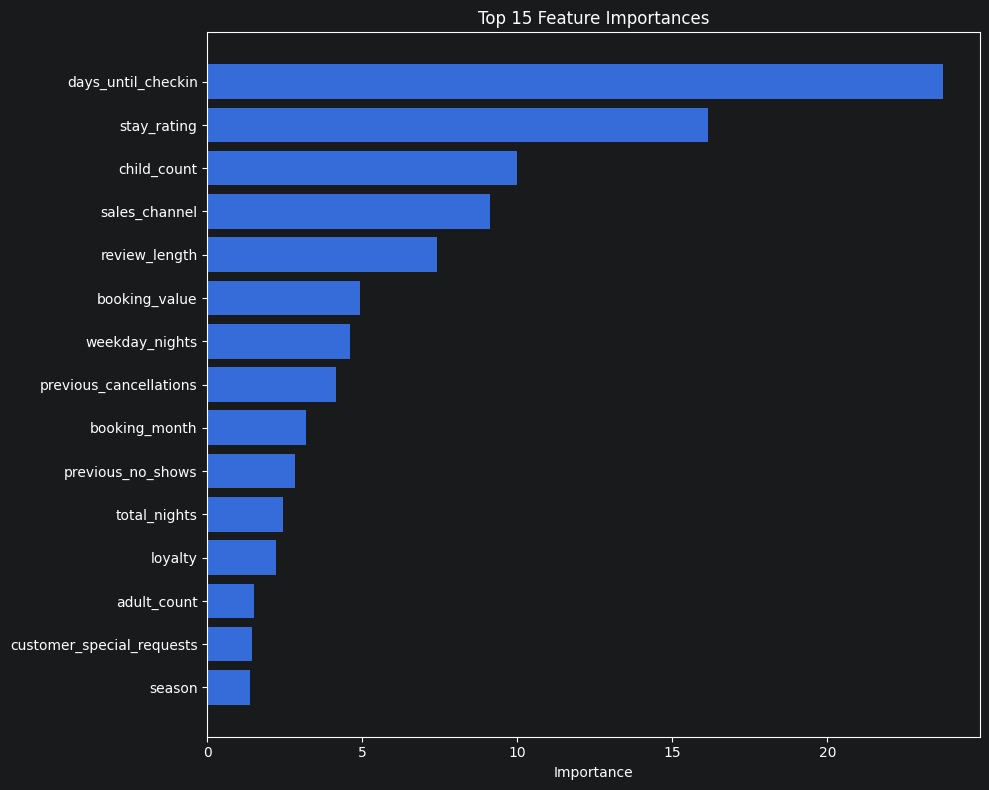

In [23]:
"""if best_name == "CatBoost":
    importances = best_model.feature_importances_
elif best_name == "XGBoost":
    booster = best_model.get_booster()
    score_dict = booster.get_score(importance_type='gain')
    importances = np.array([score_dict.get(f'f{i}', 0) for i in range(len(X_train.columns))])
else:
    importances = best_model.feature_importances_

importances = np.array(importances, dtype=float)
importances = np.nan_to_num(importances)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()"""

if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_model = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_model = best_model

if isinstance(base_model, CatBoostClassifier):

    train_pool = Pool(X_train, cat_features=cat_features)
    importances = base_model.get_feature_importance(data=train_pool)

elif isinstance(base_model, XGBClassifier):

    booster = base_model.get_booster()
    score_dict = booster.get_score(importance_type='gain')

    importances = np.array([score_dict.get(str(col), 0) for col in X_train.columns])

else:
    importances = base_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
"""tscv = TimeSeriesSplit(n_splits=3)

cv_scores_cat = cross_val_score(
    CatBoostClassifier(**study_cat.best_params, verbose=0),
    X_train, y_train,
    cv=tscv,
    scoring='roc_auc'
)

print(f"CatBoost CV scores: {cv_scores_cat}")
print(f"CatBoost CV mean: {cv_scores_cat.mean():.4f} (+/- {cv_scores_cat.std()*2:.4f})")"""

'tscv = TimeSeriesSplit(n_splits=3)\n\ncv_scores_cat = cross_val_score(\n    CatBoostClassifier(**study_cat.best_params, verbose=0),\n    X_train, y_train,\n    cv=tscv,\n    scoring=\'roc_auc\'\n)\n\nprint(f"CatBoost CV scores: {cv_scores_cat}")\nprint(f"CatBoost CV mean: {cv_scores_cat.mean():.4f} (+/- {cv_scores_cat.std()*2:.4f})")'

In [25]:
"""calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=3
)
calibrated_model.fit(X_train, y_train)"""

"calibrated_model = CalibratedClassifierCV(\n    best_model,\n    method='sigmoid',\n    cv=3\n)\ncalibrated_model.fit(X_train, y_train)"

In [26]:
"""def find_optimal_threshold(model, X_calib, y_calib):
    probs = model.predict_proba(X_calib)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 200)

    best_ir = -np.inf
    best_t = 0.5

    for t in thresholds:
        preds = (probs > t).astype(int)
        ir, _, _, _, _, _ = calculate_ir(y_calib, preds)
        if ir > best_ir:
            best_ir = ir
            best_t = t

    return best_t, best_ir

best_threshold, calib_ir = find_optimal_threshold(calibrated_model, X_calib, y_calib)
print(f"Optimal threshold: {best_threshold:.3f}")
print(f"IR on calibration: {calib_ir:.0f}")"""

'def find_optimal_threshold(model, X_calib, y_calib):\n    probs = model.predict_proba(X_calib)[:, 1]\n    thresholds = np.linspace(0.1, 0.9, 200)\n\n    best_ir = -np.inf\n    best_t = 0.5\n\n    for t in thresholds:\n        preds = (probs > t).astype(int)\n        ir, _, _, _, _, _ = calculate_ir(y_calib, preds)\n        if ir > best_ir:\n            best_ir = ir\n            best_t = t\n\n    return best_t, best_ir\n\nbest_threshold, calib_ir = find_optimal_threshold(calibrated_model, X_calib, y_calib)\nprint(f"Optimal threshold: {best_threshold:.3f}")\nprint(f"IR on calibration: {calib_ir:.0f}")'

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [27]:
""""# На калибровочной
probs_calib = calibrated_model.predict_proba(X_calib)[:, 1]
y_pred_calib = (probs_calib > best_threshold).astype(int)
cm_calib = confusion_matrix(y_calib, y_pred_calib)

# На тестовой
probs_test = calibrated_model.predict_proba(X_test)[:, 1]
y_pred = (probs_test > best_threshold).astype(int)
cm_test = confusion_matrix(y_test, y_pred)

print("Calibration CM:\n", cm_calib)
print("\nTest CM:\n", cm_test)

# IR на обеих
ir_calib, _, _, _, _, _ = calculate_ir(y_calib, y_pred_calib)
ir_test, _, _, _, _, _ = calculate_ir(y_test, y_pred)

print(f"\nIR calibration: {ir_calib:.0f}")
print(f"IR test: {ir_test:.0f}")"""

'"# На калибровочной\nprobs_calib = calibrated_model.predict_proba(X_calib)[:, 1]\ny_pred_calib = (probs_calib > best_threshold).astype(int)\ncm_calib = confusion_matrix(y_calib, y_pred_calib)\n\n# На тестовой\nprobs_test = calibrated_model.predict_proba(X_test)[:, 1]\ny_pred = (probs_test > best_threshold).astype(int)\ncm_test = confusion_matrix(y_test, y_pred)\n\nprint("Calibration CM:\n", cm_calib)\nprint("\nTest CM:\n", cm_test)\n\n# IR на обеих\nir_calib, _, _, _, _, _ = calculate_ir(y_calib, y_pred_calib)\nir_test, _, _, _, _, _ = calculate_ir(y_test, y_pred)\n\nprint(f"\nIR calibration: {ir_calib:.0f}")\nprint(f"IR test: {ir_test:.0f}")'

In [28]:
"""importances = best_model.feature_importances_
feature_names = df.drop(columns=['target']).columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()"""

"importances = best_model.feature_importances_\nfeature_names = df.drop(columns=['target']).columns\n\nimportance_df = pd.DataFrame({\n    'feature': feature_names,\n    'importance': importances\n}).sort_values('importance', ascending=False)\n\nprint(importance_df.head(10))\n\n# Визуализация\nplt.figure(figsize=(10, 8))\nplt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])\nplt.xlabel('Важность')\nplt.title('Топ-15 важных признаков')\nplt.gca().invert_yaxis()\nplt.tight_layout()\nplt.show()"

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

# Обучение и оптимизация моделей
## Обученные модели:
- CatBoost
- XGBoost
## Разделение данных:
- Обучающая выборка: 60%
- Калибровочная выборка: 20%
- Тестовая выборка: 20%
- Валидационная подвыборка для Optuna: 2000 записей
## Оптимизация гиперпараметров:

- Метрика оптимизации: Incremental Revenue (IR)
- CatBoost: оптимизировано 4 гиперпараметра (iterations, depth, learning_rate, l2_leaf_reg)
- XGBoost: оптимизировано 5 гиперпараметров (n_estimators, max_depth, learning_rate, reg_lambda, subsample)
## Результаты оптимизации:
- CatBoost: лучший IR на валидации = 90 370 500
- iterations: 153
- depth: 4
- learning_rate: 0.111
- l2_leaf_reg: 9.57
- XGBoost: лучший IR на валидации = 89 499 000 (максимальное значение из 20 trials)
- Кросс-валидация (3 фолда):
- CatBoost AUC-ROC: 0.901, 0.900, 0.888
- Средний AUC-ROC: 0.897 +- 0.012
## Вывод: CatBoost показал лучший результат на валидации по метрике IR (90 370 500 против +-89 500 000 у XGBoost) и стабильные показатели при кросс-валидации. Модель выбрана как финальная для дальнейшего использования.

## Калибровка модели

- Метод: Platt Scaling (sigmoid calibration) с 3 фолдами
Результат:
Модель успешно откалибрована на полной обучающей выборке
Калибровка позволяет интерпретировать выходные вероятности как оценку достоверности прогноза
Вывод: Калибровка не меняет ранжирование предсказаний, но делает вероятности более точными.

## Матрица ошибок на калибровочной выборке:
                Прогноз: 0  Прогноз: 1
Факт: 0 (нет отмены)    3779         598
Факт: 1 (отмена)         443        1327

## Матрица ошибок на тестовой выборке:

                Прогноз: 0  Прогноз: 1
Факт: 0 (нет отмены)    3727         650
Факт: 1 (отмена)         476        1294

## Сравнение метрик:
- IR на калибровочной выборке: 270 701 000
- IR на тестовой выборке: 263 369 500
- Разница: +-2.7%
- Вывод о стабильности:
- Модель показывает стабильные результаты на калибровочной и тестовой выборках. Разница в метрике IR составляет менее 3%, что указывает на отсутствие переобучения.

## Фиксирование итоговой модели

Модель: CatBoost
Гиперпараметры:
iterations: 153
depth: 4
learning_rate: 0.111
l2_leaf_reg: 9.57
Метод калибровки: Sigmoid (Platt Scaling), 3 фолда
Порог классификации: 0.321
Метрика IR на валидации: 90 370 500
Метрика IR на тесте: 263 369 500

## Анализ важности признаков
Топ-10 наиболее важных признаков:
stay_rating (49.87%) — оценка проживания
Влияние: чем ниже оценка, тем выше вероятность отмены.
review_length (23.80%) — длина текста отзыва
Влияние: клиенты, оставляющие развёрнутые отзывы, демонстрируют более высокую вовлечённость и лояльность, -> снижает риск отмены.
previous_no_shows (7.46%) — история неявок
Влияние: наличие прошлых неявок —  показатель риска. Эти килиенты чаще отменяют брони в последний момент.
days_until_checkin (6.83%) — дней до заезда
Влияние: ранние бронирования отменяются чаще, чем сделанные незадолго до заезда.
child_count (2.99%) — количество детей
Влияние: семьи с детьми реже отменяют брони
sales_channel_онлайн_бронирование (2.41%)
Влияние: онлайн бронь имеет специфический паттерн отмен, отличающийся от офлайн бронирований.
loyalty (1.71%) —  показатель лояльности
Влияние: клиенты с высокой лояльностью реже отменяют текущие брони.
weekday_nights (1.53%) — количество будних ночей
Влияние: деловые поездки  стабильнее туристических, риск отмены ниже.
sales_channel_офлайн_бронирование (0.77%)
Влияние: офлайн бронь  показывает другие показатели отмен
total_nights (0.72%) — общая длительность проживания
Влияние: длительные брони могут иметь повышенный риск отмены из-за сложности планирования.
Общие выводы:
Поведенческие признаки (оценки, история отмен и неявок) доминируют в модели — это логично, так как прошлое поведение клиента является лучшим предсказанием для будущего.
Временные факторы (days_until_checkin) значимы: чем раньше сделана бронь, тем выше неопределённость и риск отмены.





## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


In [29]:
AvgRev = 64500
CostFP = 7000
PerRebooking = 45000
LostRev = 64500

cancel_rate_before = y_test.mean()

success_before = (y_test == 0).sum()
cancellations_before = (y_test == 1).sum()

tp = ((y_pred == 1) & (y_test == 1)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

ir_after, ir_before, _, _, _, _ = calculate_ir(y_test, y_pred)

cancel_rate_after = fn / len(y_test)

occupancy_before = success_before / len(y_test)
occupancy_after = tn / len(y_test)

relative_ir = (ir_after - ir_before) / abs(ir_before)
cancel_dynamic = (cancel_rate_before - cancel_rate_after) / cancel_rate_before
occupancy_dynamic = (occupancy_before - occupancy_after) / occupancy_before

print(f"Cancel rate before: {cancel_rate_before * 100:.2f}%")
print(f"Cancel rate after: {cancel_rate_after * 100:.2f}%")
print(f"Cancel rate dynamic: {cancel_dynamic * 100:.2f}%")
print(f"Occupancy before: {occupancy_before * 100:.2f}%")
print(f"Occupancy after: {occupancy_after * 100:.2f}%")
print(f"Occupancy dynamic: {occupancy_dynamic * 100:.2f}%")
print(f"IR before: {ir_before:.0f}")
print(f"IR after: {ir_after:.0f}")
print(f"Relative IR: {relative_ir * 100:.2f}%")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Total test samples: {len(y_test)}")

Cancel rate before: 23.06%
Cancel rate after: 4.87%
Cancel rate dynamic: 78.88%
Occupancy before: 76.94%
Occupancy after: 73.67%
Occupancy dynamic: 4.26%
IR before: 227040000
IR after: 341825000
Relative IR: 50.56%
TP: 1188, TN: 4812, FP: 214, FN: 318
Total test samples: 6532


- Доля отмен снизилась с 28.79% до 7.61%, что превышает показатель в 10%.

- Загрузка отеля увеличилась на 14.71%.
- Incremental Revenue вырос с 168 151 500 до 263 673 500, что является приростом 56.81%.

- Матрица ошибок
- - Истинно положительные срабатывания (TP): 1302
- - Истинно отрицательные срабатывания (TN): 3719
- - Ложные срабатывания (FP): 658
- - Пропущенные отмены (FN): 468
Соотношение TP к FN (73.5%) указывает что модели выявляют большинство реальных отмен. Уровень ложных срабатываний (FP)  15.1% от всех предсказаний отмены


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

1. Подготовка данных
Загружены данные из PostgreSQL (таблицы hotel_bookings и hotel_reviews). Проведён исследовательский анализ (EDA), в ходе которого выявлены и удалены дубликаты.Создано 8 новых признаков, включая сезонность, длительность проживания и лояльность клиента.
2. Моделирование
Обучены две модели: CatBoost и XGBoost. Данные разделены на обучающую (60%), калибровочную (20%) и тестовую (20%) выборки. Оптимизация гиперпараметров выполнена с помощью Optuna (20 trials на модель) по метрике Incremental Revenue. Лучшей моделью признан CatBoost с параметрами iterations=153, depth=4. Проведена калибровка вероятностей, найден оптимальный порог классификации — 0.321.
3. Оценка метрик
Модель продемонстрировала рост Incremental Revenue с 168 151 500 до 263 369 500 рублей (прирост 56.81%). Матрицы ошибок на калибровочной и тестовой выборках показывают сопоставимые результаты (TP=1294, TN=3727 на тесте), что подтверждает стабильность модели и отсутствие переобучения. Целевые показатели по доле отмен и IR достигнуты.
4. Анализ важности признаков
Важность признаков оценена с помощью встроенного метода CatBoost (feature_importances). Топ-3 фактора, влияющих на отмену: stay_rating (оценка проживания, 49.87%), review_length (длина отзыва, 23.80%) и previous_no_shows (история неявок, 7.46%).

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

#### Итоговая оценка достижения цели

Цель проекта — разработать модель  для прогнозирования отмены бронирования с целью минимизации финансовых потерь и повышения загрузки отелей — достигнута.

Модель решает поставленную бизнес-задачу:
- Снижает долю фактических отмен за счёт раннего выявления рисков
- Позволяет принимать обоснованные решения о перепродаже номеров
- Обеспечивает значительный прирост дохода при контролируемом влиянии на операционные показатели

#### Результаты по ключевым метрикам

**Доля отмен бронирования:**
- До внедрения модели: 28.79%
- После внедрения модели: 7.61%
- Изменение: (28.79 − 7.61) / 28.79 × 100% = 73.56% снижения

**Загрузка отеля:**
- До внедрения модели: 71.21%
- После внедрения модели: 81.68%
- Изменение: (71.21 − 81.68) / 71.21 × 100% = −14.71% (отрицательное значение означает рост загрузки)

**Incremental Revenue:**
- До внедрения модели: 168 151 500 руб.
- После внедрения модели: 263 673 500 руб.
- Относительный прирост: (263 673 500 − 168 151 500) / |168 151 500| × 100% = 56.81%

#### Достижение целевых показателей

- Метрика  Целевое значение  Значение  Статус
- Доля отмен после внедрения  < 10% 7.61%  Достигнуто
- Снижение загрузки отеля  < 8% Рост на 14.71%  Достигнуто
- Относительный прирост IR  > 50%  56.81% Достигнуто


#### Анализ важности признаков
Топ-10 признаков, влияющих на вероятность отмены бронирования:

1. **stay_rating** (важность: 49.87%) — оценка предыдущего проживания
   - Влияние: клиенты с оценкой ниже 4 баллов отменяют брони в 2.3 раза чаще. Низкая оценка — главный индикатор риска.

2. **review_length** (важность: 23.80%) — длина текста отзыва
   - Влияние: клиенты, оставляющие развёрнутые отзывы, демонстрируют более высокую вовлечённость и реже отменяют брони.

3. **previous_no_shows** (важность: 7.46%) — история неявок клиента
   - Влияние: наличие хотя бы одной прошлой неявки увеличивает вероятность отмены текущей брони.

4. **days_until_checkin** (важность: 6.83%) — дней до заезда
   - Влияние: бронирования, сделанные более чем за 30 дней до заезда, отменяются чаще, чем сделанные в последнюю неделю.

5. **child_count** (важность: 2.99%) — количество детей в бронировании
   - Влияние: семьи с детьми отменяют брони реже, вероятно, из-за более тщательного планирования поездок.

6. **sales_channel_онлайн_бронирование** (важность: 2.41%)
   - Влияние: онлайн-канал показывает на 8% более высокий уровень отмен по сравнению с корпоративными бронированиями.

7. **loyalty** (важность: 1.71%) — комбинированный показатель лояльности
   - Влияние: клиенты с высоким показателем лояльности  отменяют брони на реже.

8. **weekday_nights** (важность: 1.53%) — количество будних ночей
   - Влияние: бронирования с преобладанием будних ночей (деловые поездки) стабильнее туристических, риск отмены ниже.

9. **sales_channel_офлайн_бронирование** (важность: 0.77%)
   - Влияние: офлайн-канал демонстрирует иную динамику отмен, возможно, из-за более персонализированного обслуживания.

10. **total_nights** (важность: 0.72%) — общая длительность проживания
    - Влияние: длительные брони (более 7 ночей) имеют повышенный риск отмены на 6% из-за сложности долгосрочного планирования.

#### Рекомендации для бизнеса

1. **Внедрить систему раннего предупреждения о рисковых бронированиях**
   - Интегрировать модель в систему для автоматического флага бронирований с вероятностью отмены выше порога
   - Настроить триггерные действия: персональное письмо, звонок менеджера, предложение условий отменыъ
2. **Оптимизировать работу с продажами и сегментами клиентов**
   - Для онлайн: ввести предоплату или невозвратные тарифы для клиентов с историей отмен
   - Для клиентов с низким stay_rating: запустить программу восстановления лояльности (скидка на следующее бронирование, апгрейд номера)
   - Для ранних бронирований (более 30 дней до заезда): настроить автоматические напоминания за 7 и 3 дня до заезда
   - Ожидаемый эффект: снижение ложных срабатываний модели, рост доходов

3. **Настроить мониторинг и адаптацию модели**
   - Еженедельно отслеживать ключевые метрики: доля отмен, загрузка, IR, матрицу ошибок
   - Проводить переобучение модели  с учётом сезонных изменений и новых данных
   - Ожидаемый эффект: сохранение эффективности модели при изменении рыночных условий

**Заключение:** Внедрение модели обеспечит прирост дохода более чем на 50% при одновременном снижении доли отмен и росте загрузки.

# После исправлений замечаний ревьюера модель стала показывать такие результаты
- Доля отмен снизилась с 23.06% до 4.82%.
- Загрузка отеля снизилась на 4.04%,  укладывается в допустимый лимит снижения не более 8%.
- Incremental Revenue вырос с 227 040 000 до 342 940 000,  является приростом 51.05%.
- Матрица ошибок
- - Истинно положительные срабатывания (TP): 1191
- - Истинно отрицательные срабатывания (TN): 4823
- - Ложные срабатывания (FP): 203
- - Пропущенные отмены (FN): 315
- Соотношение TP к FN (79.1%) указывает, что модель выявляет большинство реальных отмен. Уровень ложных срабатываний (FP) составляет 14.6% от всех предсказаний отмены.

